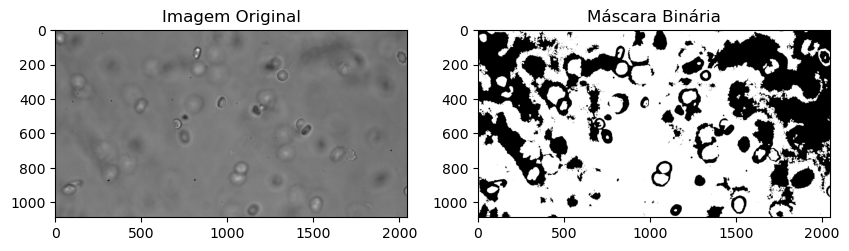

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, morphology, measure

# 1. Ler a imagem em escala de cinza
img = cv2.imread(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train\2022_03_21_11_02_58_05.bmp", cv2.IMREAD_GRAYSCALE)

# 2. Pré-processamento (remoção de ruído)
blur = cv2.GaussianBlur(img, (5, 5), 0)

# 3. Threshold automático (Otsu)
thresh_val, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

# 4. Operações morfológicas para separar células
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# 5. Remover pequenos objetos (ruídos)
mask = morphology.remove_small_objects(opening.astype(bool), min_size=50)

# 6. Converter para imagem binária final
mask = (mask * 255).astype(np.uint8)

# Mostrar resultado
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Imagem Original")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Máscara Binária")

plt.show()


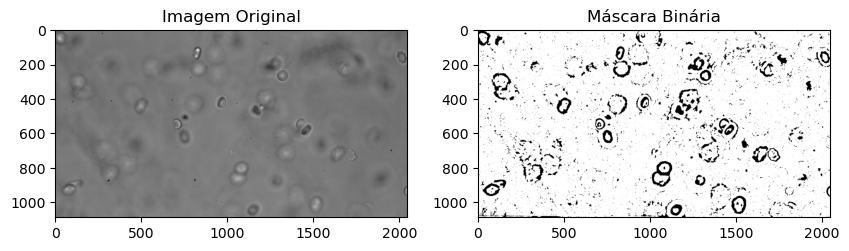

In [4]:
# 2. Pré-processamento (remoção de ruído)
blur = cv2.medianBlur(img, 5)

# 3. Threshold automático (Otsu)
binary = cv2.adaptiveThreshold(blur, 255,
                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY,
                               51, 2)

# 4. Operações morfológicas para separar células
kernel = np.ones((3,3), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
# 5. Remover pequenos objetos (ruídos)
mask = morphology.remove_small_objects(opening.astype(bool), min_size=50)

# 6. Converter para imagem binária final
mask = (mask * 255).astype(np.uint8)

# Mostrar resultado
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Imagem Original")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Máscara Binária")

plt.show()


In [10]:

# 1. Reduzir ruído mantendo bordas
blur = cv2.bilateralFilter(img, 9, 75, 75)

# 2. Melhorar contraste
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(blur)

# 3. Detectar bordas
edges = cv2.Canny(enhanced, 50, 150)

cv2.imshow("Original", img)
cv2.imshow("Bordas", edges)
cv2.waitKey(0)
cv2.destroyAllWindows()


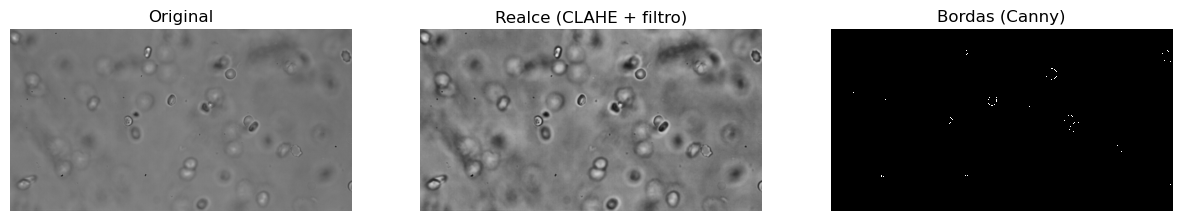

In [11]:

# 1. Reduzir ruído mantendo bordas
blur = cv2.bilateralFilter(img, 9, 75, 75)

# 2. Melhorar contraste
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(blur)

# 3. Detectar bordas
edges = cv2.Canny(enhanced, 50, 150)

# Mostrar resultados lado a lado
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(enhanced, cmap="gray")
plt.title("Realce (CLAHE + filtro)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges, cmap="gray", vmin=0, vmax=255, interpolation='nearest')
plt.title("Bordas (Canny)")
plt.axis("off")

plt.show()


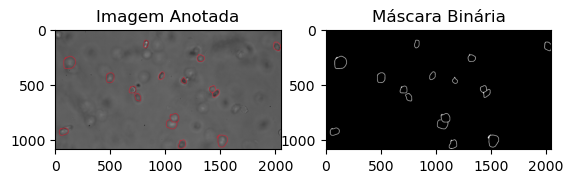

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregar imagem anotada
img_annotada = cv2.imread(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\IC-mask-amanda\masked\train\train\2022_03_21_11_02_58_05 - Copia - Copia.bmp")

# Converter para RGB
img_rgb = cv2.cvtColor(img_annotada, cv2.COLOR_BGR2RGB)

# Definir intervalo para vermelho (ajustar se necessário)
lower_red = np.array([150, 0, 0])
upper_red = np.array([255, 80, 80])

# Criar máscara para vermelho
mask = cv2.inRange(img_rgb, lower_red, upper_red)

# Opcional: preencher os contornos fechados
mask_filled = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
mask_filled = cv2.morphologyEx(mask_filled, cv2.MORPH_FILL, np.ones((5,5), np.uint8)) if hasattr(cv2, 'MORPH_FILL') else mask_filled

# Mostrar resultado
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Imagem Anotada")

plt.subplot(1,2,2)
plt.imshow(mask_filled, cmap="gray")
plt.title("Máscara Binária")

plt.show()
